In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# BASE_PATH = '/Volumes/Reading/Projects/Empathy-LLM/Llama-3.2-3B-Instruct/'
BASE_PATH = '/content/drive/MyDrive/Project-4/'

EMOTIONS = ['afraid', 'angry', 'anxious', 'devastated', 'lonely', 'sad',
            'terrified', 'furious', 'grateful', 'hopeful', 'faithful']

STEP1_PATH = BASE_PATH 
STEP2_PATH = BASE_PATH 
os.makedirs(STEP2_PATH, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
def load_prompt_embeddings_npz(filepath, emotions):
    """Load prompt_embeddings.npz → X_all (num_layers, num_samples, hidden_dim), y_all.

    Transposed layout (layers first) makes per-layer slicing a zero-copy view.
    Stored as float32 to avoid sklearn silently upcasting float16 to float64.
    """
    data = np.load(filepath)

    # Parse keys: "{context}_{prompt_idx}_{layer_idx}"
    context_prompt_layers = defaultdict(lambda: defaultdict(dict))
    for key in data.files:
        parts = key.rsplit('_', 2)
        context, prompt_idx, layer_idx = parts[0], int(parts[1]), int(parts[2])
        context_prompt_layers[context][prompt_idx][layer_idx] = data[key]
    del data  # close NPZ handle — no longer needed

    num_layers = max(
        l for ctx in context_prompt_layers.values()
        for prompt in ctx.values() for l in prompt.keys()
    ) + 1

    X_all, y_all = [], []
    for emotion in emotions:
        for prompt_idx in sorted(context_prompt_layers[emotion].keys()):
            layer_embs = [context_prompt_layers[emotion][prompt_idx][l] for l in range(num_layers)]
            X_all.append(layer_embs)
            y_all.append(emotion)

    del context_prompt_layers  # free intermediate dict before allocating numpy arrays

    # Transpose to (num_layers, num_samples, hidden_dim) for zero-copy layer slicing
    X_all = np.array(X_all, dtype=np.float32).transpose(1, 0, 2)
    return X_all, np.array(y_all), num_layers


def load_context_embeddings_npz(filepath, emotions):
    """Load context_embeddings.npz → dict {emotion: {layer: embedding}}."""
    data = np.load(filepath)
    context_embs = defaultdict(dict)
    for key in data.files:
        parts = key.rsplit('_', 1)
        context, layer_idx = parts[0], int(parts[1])
        context_embs[context][layer_idx] = data[key]
    return context_embs

In [6]:
def train_probe(X_train_np, y_train, X_test_np, y_test, device,
               penalty='l2', C=1.0, epochs=500, batch_size=256, lr=1e-3):
    """Train a logistic regression probe on GPU via PyTorch.

    L2: weight_decay in Adam. L1: explicit penalty added to loss.
    Sparsity approximated by |w| < 1e-4 threshold (gradient methods don't give exact zeros).
    """
    label_map  = {e: i for i, e in enumerate(sorted(set(y_train)))}
    classes    = sorted(label_map, key=label_map.get)
    num_classes = len(classes)
    hidden_dim  = X_train_np.shape[1]

    X_tr = torch.tensor(X_train_np, dtype=torch.float32, device=device)
    X_te = torch.tensor(X_test_np,  dtype=torch.float32, device=device)
    y_tr = torch.tensor([label_map[y] for y in y_train], dtype=torch.long, device=device)
    y_te_np = np.array([label_map[y] for y in y_test])

    probe = nn.Linear(hidden_dim, num_classes).to(device)
    weight_decay = (1.0 / C) if penalty == 'l2' else 0.0
    lambda_l1   = (1.0 / C) if penalty == 'l1' else 0.0
    optimizer   = torch.optim.Adam(probe.parameters(), lr=lr, weight_decay=weight_decay)
    criterion   = nn.CrossEntropyLoss()

    probe.train()
    for _ in range(epochs):
        perm = torch.randperm(len(X_tr), device=device)
        for i in range(0, len(X_tr), batch_size):
            idx = perm[i:i + batch_size]
            optimizer.zero_grad()
            loss = criterion(probe(X_tr[idx]), y_tr[idx])
            if lambda_l1 > 0:
                loss = loss + lambda_l1 * probe.weight.abs().sum()
            loss.backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        preds = probe(X_te).argmax(dim=1).cpu().numpy()

    acc      = (preds == y_te_np).mean()
    coef     = probe.weight.detach().cpu().numpy()  # (num_classes, hidden_dim)
    sparsity = (np.abs(coef) < 1e-4).mean()
    return acc, sparsity, coef, classes

In [7]:
print("Loading prompt embeddings from NPZ...")
X_all, y_all, num_layers = load_prompt_embeddings_npz(STEP1_PATH + 'prompt_embeddings.npz', EMOTIONS)
print(f"  X_all shape: {X_all.shape}  |  num_layers: {num_layers}")

print("Loading context embeddings from NPZ...")
context_embs = load_context_embeddings_npz(STEP1_PATH + 'context_embeddings.npz', EMOTIONS)
print(f"  Contexts loaded: {list(context_embs.keys())}")

Loading prompt embeddings from NPZ...
  X_all shape: (29, 2200, 3072)  |  num_layers: 29
Loading context embeddings from NPZ...
  Contexts loaded: ['afraid', 'angry', 'anxious', 'devastated', 'lonely', 'sad', 'terrified', 'furious', 'grateful', 'hopeful', 'faithful']


In [8]:
# --- PROBING: Prompt Embeddings (L1 + L2 per layer on GPU) ---
indices = np.arange(len(y_all))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_all)
y_train, y_test = y_all[train_idx], y_all[test_idx]

l1_accuracies = {}
l2_accuracies = {}
l1_sparsity   = {}
top_features  = {}

print(f"\nTraining L1 and L2 probes across {num_layers} layers on {device}...")
for layer in range(num_layers):
    X = X_all[layer]   # zero-copy view — (num_samples, hidden_dim)

    # Standardize on CPU before sending to GPU
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X[train_idx])
    X_test  = scaler.transform(X[test_idx])

    acc_l1, spar, coef, classes = train_probe(X_train, y_train, X_test, y_test,
                                               device, penalty='l1')
    acc_l2, _,    _,    _       = train_probe(X_train, y_train, X_test, y_test,
                                               device, penalty='l2')
    l1_accuracies[layer] = acc_l1
    l2_accuracies[layer] = acc_l2
    l1_sparsity[layer]   = spar
    print(f"  Layer {layer:2d} | L1: {acc_l1:.4f} | L2: {acc_l2:.4f} | Sparsity: {spar:.2%}")

# Extract top active dimensions at the best L1 layer (once, after loop)
best_layer = max(l1_accuracies, key=l1_accuracies.get)
print(f"\nBest L1 layer: {best_layer} (accuracy: {l1_accuracies[best_layer]:.4f})")
scaler_best  = StandardScaler()
X_best_train = scaler_best.fit_transform(X_all[best_layer][train_idx])
X_best_test  = scaler_best.transform(X_all[best_layer][test_idx])
_, _, coef_best, classes_best = train_probe(X_best_train, y_train, X_best_test, y_test,
                                             device, penalty='l1')
for i, emotion in enumerate(classes_best):
    top_dims = np.argsort(np.abs(coef_best[i]))[-20:][::-1]
    top_features[emotion] = top_dims.tolist()


Training L1 and L2 probes across 29 layers on cuda...
  Layer  0 | L1: 0.0977 | L2: 0.5273 | Sparsity: 50.05%
  Layer  1 | L1: 0.1000 | L2: 0.4795 | Sparsity: 49.67%
  Layer  2 | L1: 0.1000 | L2: 0.5250 | Sparsity: 49.88%
  Layer  3 | L1: 0.1364 | L2: 0.5250 | Sparsity: 49.54%
  Layer  4 | L1: 0.1614 | L2: 0.6273 | Sparsity: 50.04%
  Layer  5 | L1: 0.1227 | L2: 0.6386 | Sparsity: 48.93%
  Layer  6 | L1: 0.1295 | L2: 0.6295 | Sparsity: 48.71%
  Layer  7 | L1: 0.1500 | L2: 0.6409 | Sparsity: 49.17%
  Layer  8 | L1: 0.1773 | L2: 0.6523 | Sparsity: 48.86%
  Layer  9 | L1: 0.1477 | L2: 0.6523 | Sparsity: 48.89%
  Layer 10 | L1: 0.1523 | L2: 0.6273 | Sparsity: 48.93%
  Layer 11 | L1: 0.1886 | L2: 0.6409 | Sparsity: 49.06%
  Layer 12 | L1: 0.1614 | L2: 0.6523 | Sparsity: 49.10%
  Layer 13 | L1: 0.2159 | L2: 0.6886 | Sparsity: 48.65%
  Layer 14 | L1: 0.1455 | L2: 0.6477 | Sparsity: 48.24%
  Layer 15 | L1: 0.1932 | L2: 0.6727 | Sparsity: 48.73%
  Layer 16 | L1: 0.1455 | L2: 0.6636 | Sparsity: 

In [9]:
# --- CONTEXT EMBEDDING ANALYSIS: Pairwise cosine similarity per layer ---
# (11 prototypes per layer — cosine similarity reveals how well-separated emotions are)
print("\nComputing pairwise cosine similarity between context embeddings per layer...")

avg_cosine_per_layer = {}
for layer in range(num_layers):
    matrix = np.stack([context_embs[e][layer] for e in EMOTIONS])  # (11, hidden_dim)
    sim_matrix = cosine_similarity(matrix)                          # (11, 11)
    # Average off-diagonal similarity (lower = better-separated emotions)
    mask = ~np.eye(len(EMOTIONS), dtype=bool)
    avg_cosine_per_layer[layer] = sim_matrix[mask].mean()

best_sep_layer = min(avg_cosine_per_layer, key=avg_cosine_per_layer.get)
print(f"  Best-separated layer: {best_sep_layer} (avg cosine = {avg_cosine_per_layer[best_sep_layer]:.4f})")


Computing pairwise cosine similarity between context embeddings per layer...
  Best-separated layer: 28 (avg cosine = 0.9633)


In [10]:
# Save results
results = {
    'l1_accuracies':  {str(k): v for k, v in l1_accuracies.items()},
    'l2_accuracies':  {str(k): v for k, v in l2_accuracies.items()},
    'l1_sparsity':    {str(k): v for k, v in l1_sparsity.items()},
    'top_features':   top_features,
    'best_l1_layer':  int(max(l1_accuracies, key=l1_accuracies.get)),
    'context_avg_cosine_per_layer': {str(k): float(v) for k, v in avg_cosine_per_layer.items()},
    'best_separated_layer': int(best_sep_layer),
}
with open(STEP2_PATH + 'probing_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nSaved: probing_results.json")


Saved: probing_results.json


Saved: l1_vs_l2_probing.png


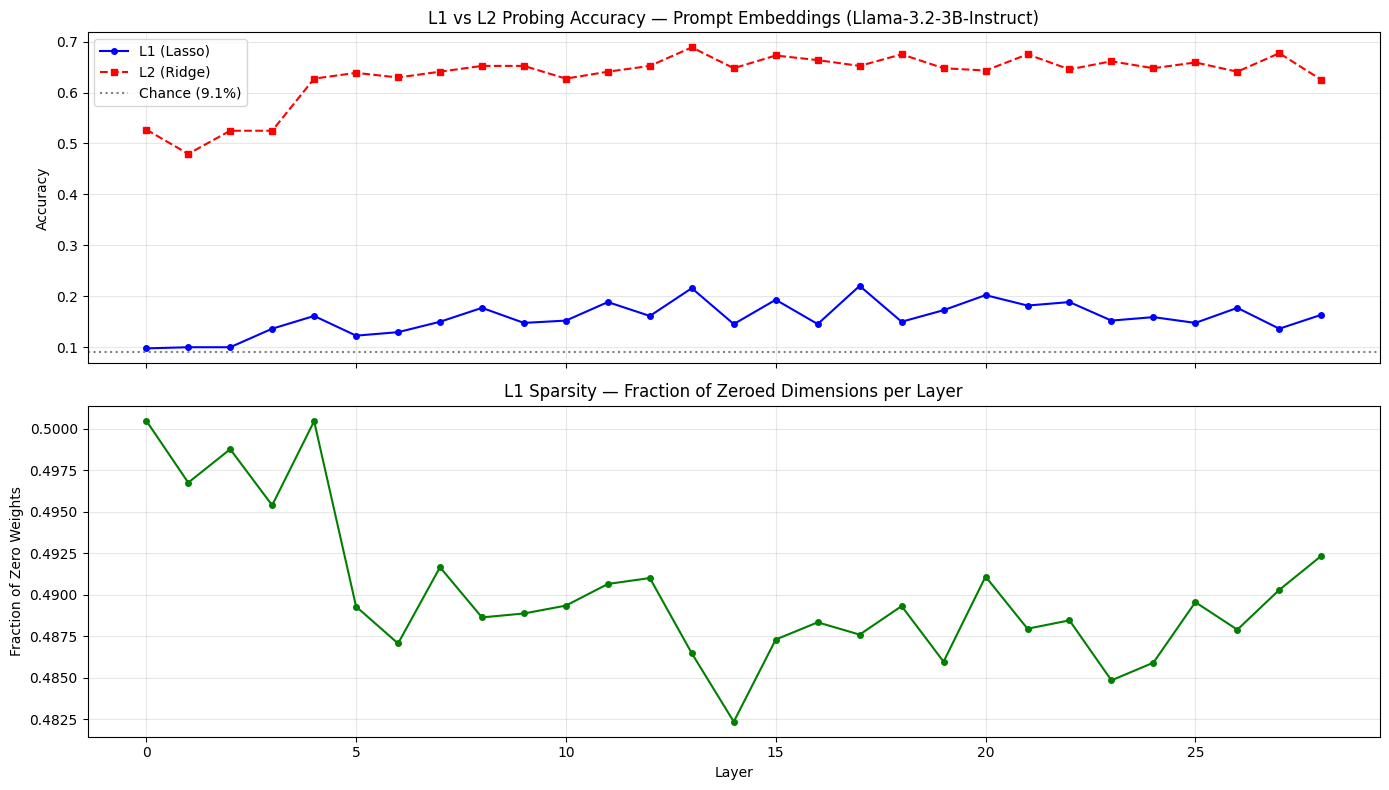

In [11]:
# Plot 1: L1 vs L2 accuracy + sparsity across layers
layers = list(range(num_layers))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(layers, [l1_accuracies[l] for l in layers], 'b-o', label='L1 (Lasso)', markersize=4)
ax1.plot(layers, [l2_accuracies[l] for l in layers], 'r--s', label='L2 (Ridge)', markersize=4)
ax1.axhline(1 / len(EMOTIONS), color='gray', linestyle=':', label=f'Chance ({1/len(EMOTIONS):.1%})')
ax1.set_ylabel('Accuracy')
ax1.set_title('L1 vs L2 Probing Accuracy — Prompt Embeddings (Llama-3.2-3B-Instruct)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(layers, [l1_sparsity[l] for l in layers], 'g-o', markersize=4)
ax2.set_ylabel('Fraction of Zero Weights')
ax2.set_xlabel('Layer')
ax2.set_title('L1 Sparsity — Fraction of Zeroed Dimensions per Layer')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(STEP2_PATH + 'l1_vs_l2_probing.png', dpi=300)
print("Saved: l1_vs_l2_probing.png")

Saved: context_cosine_heatmap.png


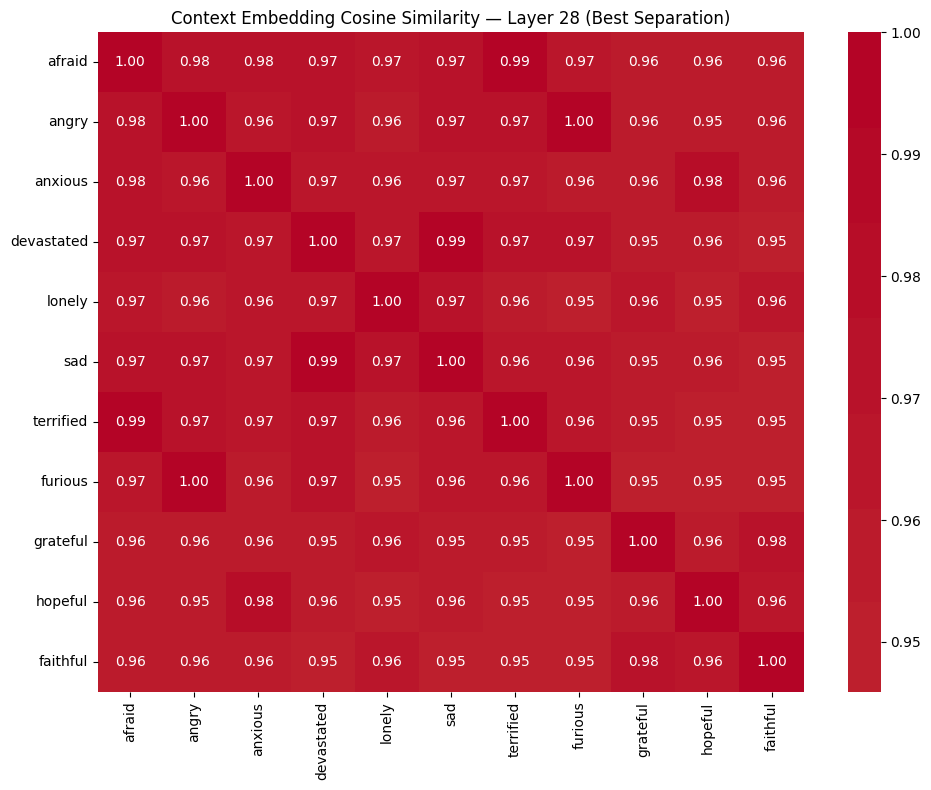

In [12]:
# Plot 2: Pairwise cosine similarity heatmap at best-separated layer
best_matrix = np.stack([context_embs[e][best_sep_layer] for e in EMOTIONS])
sim_matrix  = cosine_similarity(best_matrix)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, xticklabels=EMOTIONS, yticklabels=EMOTIONS,
            annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title(f'Context Embedding Cosine Similarity — Layer {best_sep_layer} (Best Separation)')
plt.tight_layout()
plt.savefig(STEP2_PATH + 'context_cosine_heatmap.png', dpi=300)
print("Saved: context_cosine_heatmap.png")

Saved: context_separation_per_layer.png


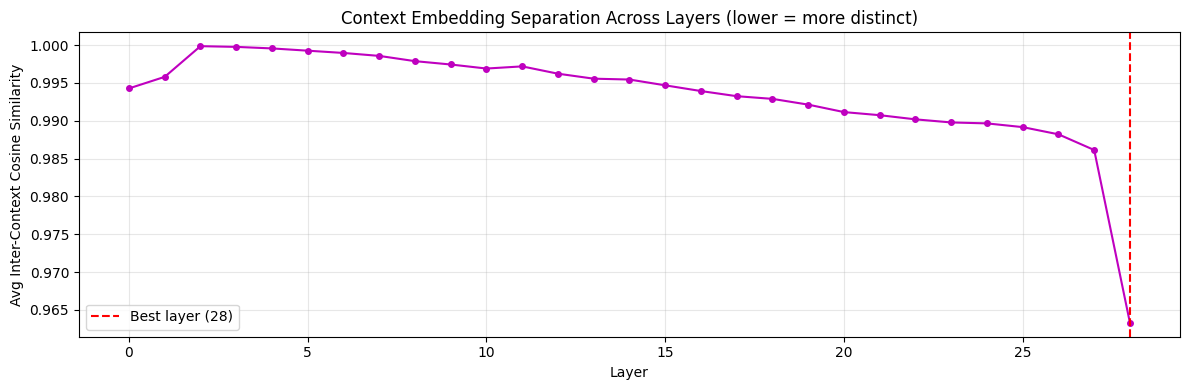

In [13]:
# Plot 3: Average inter-context cosine similarity across layers
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(layers, [avg_cosine_per_layer[l] for l in layers], 'm-o', markersize=4)
ax.axvline(best_sep_layer, color='red', linestyle='--', label=f'Best layer ({best_sep_layer})')
ax.set_xlabel('Layer')
ax.set_ylabel('Avg Inter-Context Cosine Similarity')
ax.set_title('Context Embedding Separation Across Layers (lower = more distinct)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(STEP2_PATH + 'context_separation_per_layer.png', dpi=300)
print("Saved: context_separation_per_layer.png")